In [3]:
pip install -U langgraph

In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [5]:
class EmployeeState(TypedDict):
  employee_name:str
  monthly_salary:int
  working_days:int
  completed_projects:int

  yearly_salary:int
  bonus_amount:int
  project_status:str
  summary:str

In [13]:
def yearly_salary(state:EmployeeState):
  monthly_salary=state['monthly_salary']
  state['yearly_salary']=12*monthly_salary
  return {
      'yearly_salary':state['yearly_salary']
  }

def calculate_bonus(state:EmployeeState):
  state['bonus_amount']=state['monthly_salary']*2
  return {
      'bonus_amount':state['bonus_amount']
  }

def project_evaluation(state:EmployeeState):
  if state['completed_projects']>7:
    state['project_status']="Excellent"
  else:
    state['project_status']='Average'

  return {
      'project_status':state['project_status']
  }

def summary(state:EmployeeState):
  state['summary']=f"{state['employee_name']} has a monthly salary of {state['monthly_salary']} and project status is {state['project_status']}"
  return {
      'summary':state['summary']
  }

In [14]:
graph= StateGraph(EmployeeState)
graph.add_node('yearly_salary',yearly_salary)
graph.add_node('calculate_bonus',calculate_bonus)
graph.add_node('project_evaluation',project_evaluation)
graph.add_node('summary',summary)

graph.add_edge(START,'yearly_salary')
graph.add_edge(START,'calculate_bonus')
graph.add_edge(START,'project_evaluation')
graph.add_edge('yearly_salary','summary')
graph.add_edge('calculate_bonus','summary')
graph.add_edge('project_evaluation','summary')
graph.add_edge('summary',END)

workflow=graph.compile()

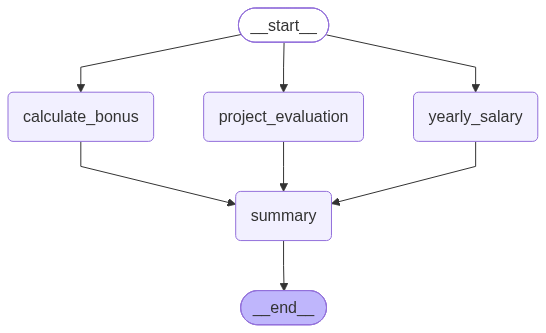

In [15]:
workflow

In [16]:
initial_state={
  "employee_name":'abhi',
  "monthly_salary":60000,
  "working_days":5,
  "completed_projects":8
}

In [17]:
final_state=workflow.invoke(initial_state)

In [18]:
print(final_state)

{'employee_name': 'abhi', 'monthly_salary': 60000, 'working_days': 5, 'completed_projects': 8, 'yearly_salary': 720000, 'bonus_amount': 120000, 'project_status': 'Excellent', 'summary': 'abhi has a monthly salary of 60000 and project status is Excellent'}
